In [4]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("default")

BASE_DIR = Path.cwd().parent

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

In [6]:
#Load Dataset
fund = pd.read_csv(DATA_RAW / "01_fund_master.csv")

nav = pd.read_csv(DATA_PROCESSED / "nav_history_clean.csv")

aum = pd.read_csv(DATA_RAW / "03_aum_by_fund_house.csv")

sip = pd.read_csv(DATA_RAW / "04_monthly_sip_inflows.csv")

category = pd.read_csv(DATA_RAW / "05_category_inflows.csv")

folio = pd.read_csv(DATA_RAW / "06_industry_folio_count.csv")

performance = pd.read_csv(DATA_PROCESSED / "scheme_performance_clean.csv")

txn = pd.read_csv(DATA_PROCESSED / "transactions_clean.csv")

holdings = pd.read_csv(DATA_RAW / "09_portfolio_holdings.csv")

benchmark = pd.read_csv(DATA_RAW / "10_benchmark_indices.csv")

#----------------------Basic EDA----------------------

# Analysis 1: Fund House Distribution

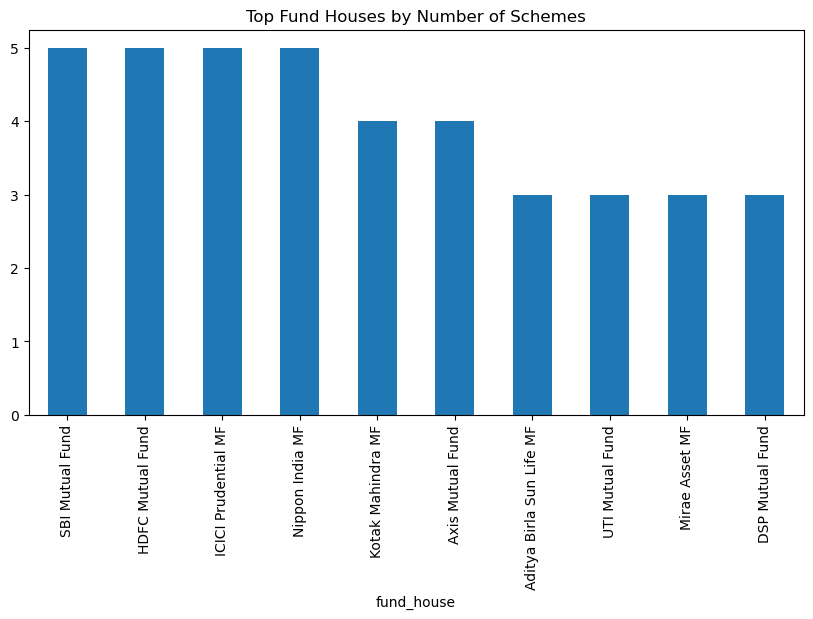

In [9]:
fund["fund_house"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Fund Houses by Number of Schemes")
plt.show()

Insights

SBI Mutual Fund, HDFC Mutual Fund, ICICI Prudential Mutual Fund, and Nippon India Mutual Fund have the highest number of schemes (5 each).

Kotak and Axis Mutual Fund follow closely with 4 schemes each.

The industry is dominated by a few large asset management companies offering diversified investment products.

Larger fund houses appear to maintain broader product portfolios across multiple categories.

# Analysis 2: Category Distribution

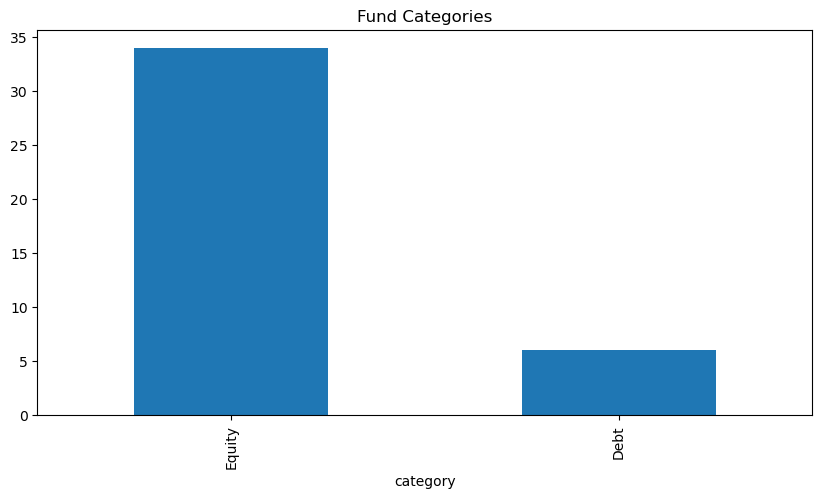

In [12]:
fund["category"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Fund Categories")
plt.show()

Insights

Equity funds dominate the dataset with approximately 30–35 schemes.

Debt funds represent a much smaller portion of the available schemes.

The distribution reflects a strong market preference toward equity-oriented investments.

Fund houses appear to focus primarily on growth and wealth creation products.

# Analysis 3: AUM by Fund House

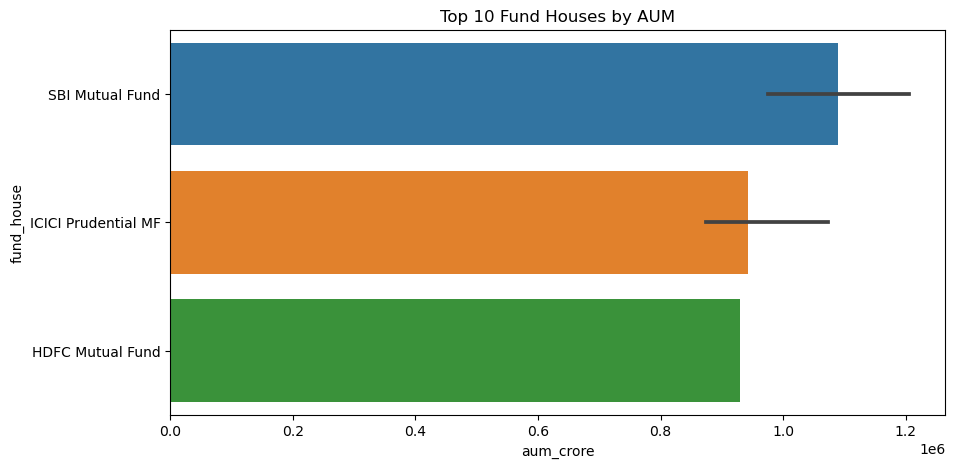

In [15]:
top_aum = aum.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_aum,
    x="aum_crore",
    y="fund_house"
)

plt.title("Top 10 Fund Houses by AUM")
plt.show()

Insights

SBI Mutual Fund has the highest Assets Under Management (AUM) among the fund houses analyzed.

ICICI Prudential Mutual Fund ranks second, followed by HDFC Mutual Fund.

The top fund houses collectively manage a substantial share of industry assets.

Higher AUM indicates stronger investor confidence and larger market presence.

# Analysis 4: SIP Inflow Trend

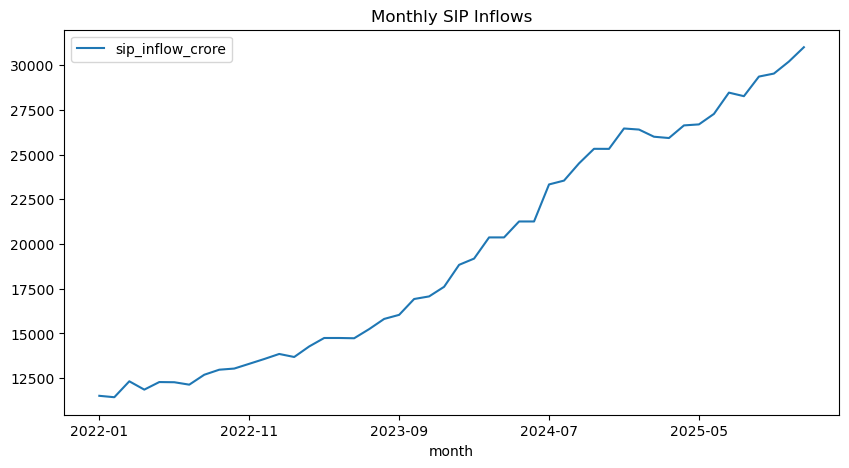

In [18]:
sip.plot(
    x=sip.columns[0],
    y=sip.columns[1],
    figsize=(10,5)
)

plt.title("Monthly SIP Inflows")
plt.show()

Insights

SIP inflows demonstrate a consistent upward trend over time.

Growing SIP contributions indicate increasing retail investor participation.

Investors are increasingly adopting disciplined, long-term investment strategies.

Rising SIP inflows contribute to the stability of mutual fund cash flows.

# Analysis 5: Investor Demographics

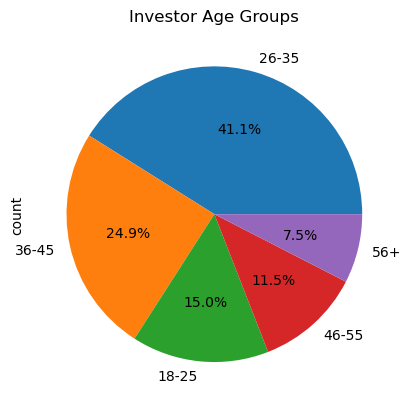

In [21]:
txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Groups")
plt.show()

Insights

The 26–35 age group constitutes the largest investor segment at approximately 41.1%.

Investors aged 36–45 account for around 24.9% of the total investor base.

Young investors (18–25 years) contribute nearly 15%, indicating early adoption of mutual fund investing.

Participation decreases gradually among older age groups.

# Analysis 6: Gender Distribution

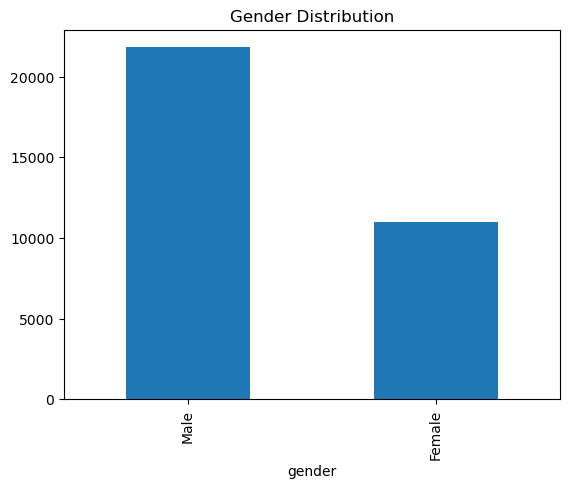

In [24]:
txn["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.show()

Insights

Male investors account for more than 20,000 transactions.

Female investors account for approximately 11,000 transactions.

The investor base exhibits a noticeable gender imbalance.

There is potential for increased participation through initiatives focused on female financial inclusion.

# Analysis 7: Transaction Type

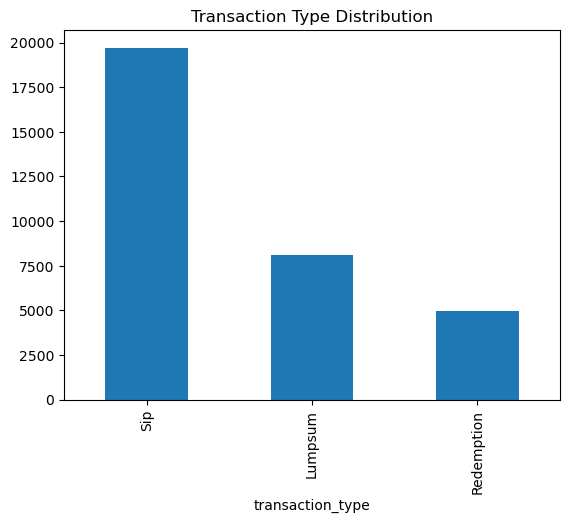

In [27]:
txn["transaction_type"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Type Distribution")
plt.show()

Insights

SIP transactions are the most frequent transaction type, approaching 20,000 records.

Lumpsum investments account for approximately 7,500 transactions.

Redemption transactions account for approximately 5,000 transactions.

The dominance of SIP transactions indicates a strong preference for systematic investing among investors.

# Analysis 8: Top Performing Funds

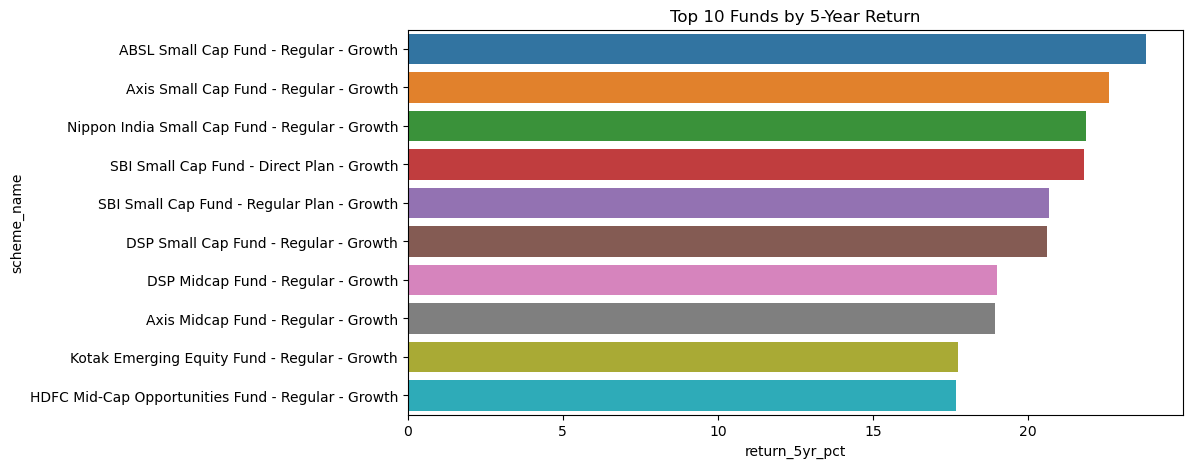

In [30]:
top_funds = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_funds,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.show()

Insights

Small-cap funds dominate the list of top-performing schemes based on 5-year returns.

ABSL Small Cap Fund, Axis Small Cap Fund, Nippon India Small Cap Fund, and SBI Small Cap Fund are among the strongest performers.

Mid-cap funds also feature prominently among the top-performing schemes.

Higher returns are generally associated with higher-risk investment categories.

# Analysis 9: Risk Grade Distribution

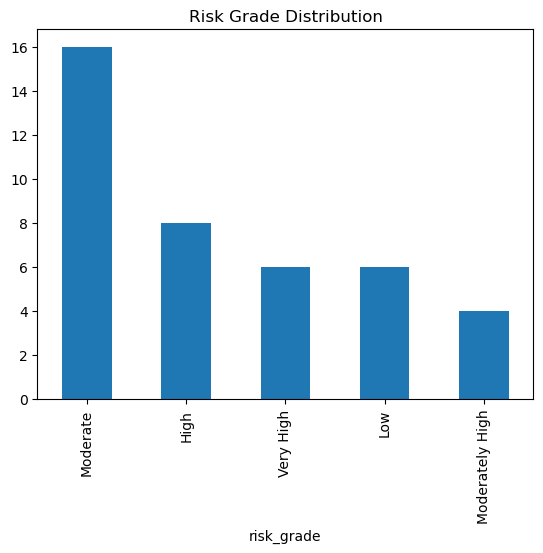

In [33]:
performance["risk_grade"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Grade Distribution")
plt.show()

Insights

Moderate-risk funds form the largest category with 16 schemes.

High-risk funds account for 8 schemes, while Very High-risk funds account for 6 schemes.

Low-risk funds also account for 6 schemes.

The distribution suggests that fund houses maintain a balanced portfolio of products across multiple risk levels.

# Analysis 10: Expense Ratio Analysis

C:\Users\public\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


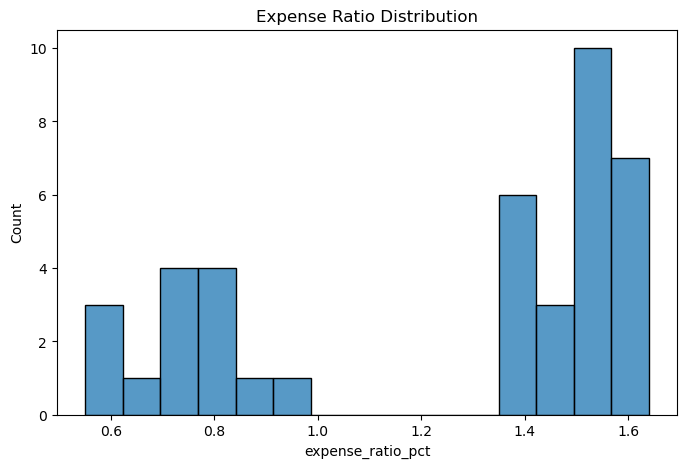

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15
)

plt.title("Expense Ratio Distribution")
plt.show()

Insights

Expense ratios range approximately from 0.5% to 1.65%.

Two distinct clusters are visible, indicating the presence of both low-cost and higher-cost schemes.

Most schemes are concentrated between 1.4% and 1.6% expense ratios.

A smaller set of funds maintains expense ratios below 1%, making them comparatively cost-efficient.

No significant outliers are observed, suggesting expense ratios remain within acceptable industry limits.

# Analysis 11: Risk Vs Return

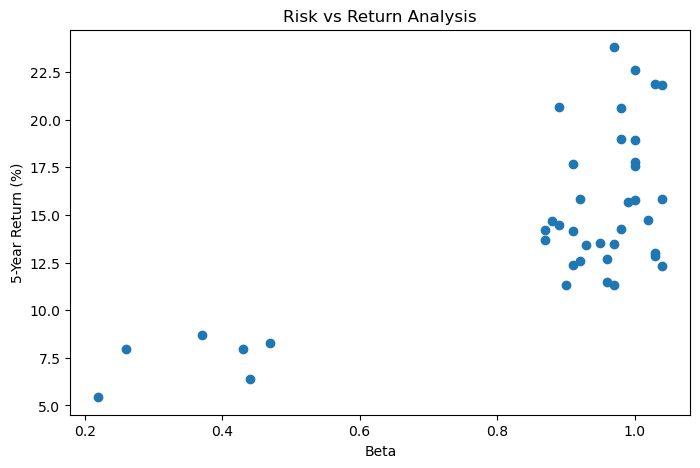

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(
    performance["beta"],
    performance["return_5yr_pct"]
)

plt.xlabel("Beta")
plt.ylabel("5-Year Return (%)")
plt.title("Risk vs Return Analysis")

plt.show()

Insights

Funds with lower beta values (0.2–0.5) generally deliver lower returns, typically between 5% and 9%.

Funds with beta values close to 1 exhibit substantially higher returns, ranging from approximately 11% to 24%.

The chart indicates a positive relationship between risk and return, consistent with financial theory.

Investors seeking higher returns may need to accept greater market risk.

A few high-beta funds generate exceptionally strong returns, making them attractive to aggressive investors.

In [56]:
print(aum.columns.tolist())
print(sip.columns.tolist())
print(category.columns.tolist())
print(folio.columns.tolist())
print(holdings.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
['month', 'category', 'net_inflow_crore']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [58]:
aum.head()
sip.head()
category.head()
folio.head()
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


#----------------------Advanced EDA----------------------

# NAV Trend Analysis

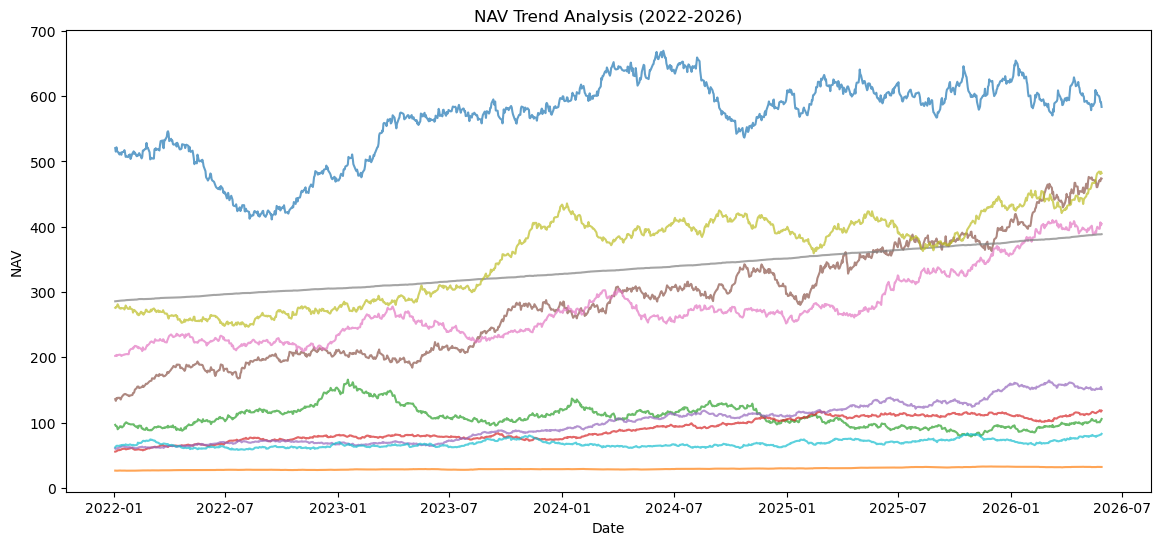

In [63]:
nav["date"] = pd.to_datetime(nav["date"])

top10 = (
    nav.groupby("amfi_code")["nav"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(14,6))

for fund in top10:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["nav"], alpha=0.7)

plt.title("NAV Trend Analysis (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

Insights

1.Most schemes show a positive long-term NAV trend between 2022 and 2026.

2.Several funds experienced short-term declines followed by strong recoveries.

3.Higher-growth schemes significantly outperformed the broader set of funds.
    
4.Long-term investing would have benefited from overall market appreciation.

# AUM Growth Analysis

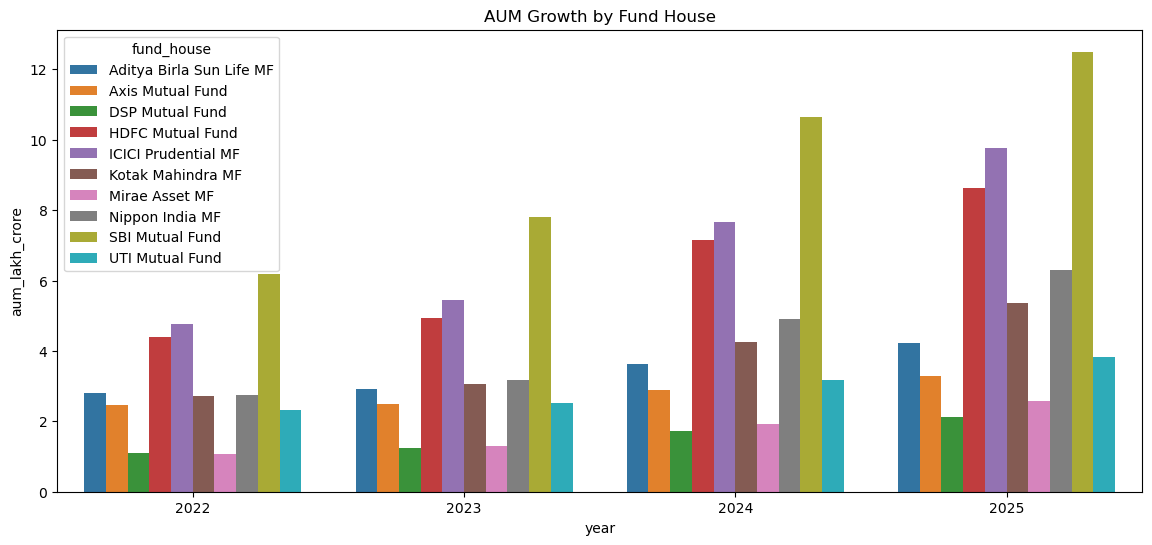

In [66]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum_year = (
    aum.groupby(
        ["year","fund_house"]
    )["aum_lakh_crore"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_year,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.show()

Insights

1.AUM increased steadily across most fund houses from 2022 to 2025.

2.SBI Mutual Fund consistently maintained the highest AUM.

3.ICICI Prudential and HDFC Mutual Fund remained among the leading asset managers.

4.Industry-wide growth suggests increasing investor participation and asset accumulation.

In [68]:
aum_year.sort_values(
    "aum_lakh_crore",
    ascending=False
).head(10)

,year,fund_house,aum_lakh_crore
38,2025,SBI Mutual Fund,12.500000
28,2024,SBI Mutual Fund,10.646667
34,2025,ICICI Prudential MF,9.770000
33,2025,HDFC Mutual Fund,8.625000
18,2023,SBI Mutual Fund,7.810000
24,2024,ICICI Prudential MF,7.653333
23,2024,HDFC Mutual Fund,7.140000
37,2025,Nippon India MF,6.300000
8,2022,SBI Mutual Fund,6.175000
14,2023,ICICI Prudential MF,5.450000


# SIP Inflow Trend + Milestone

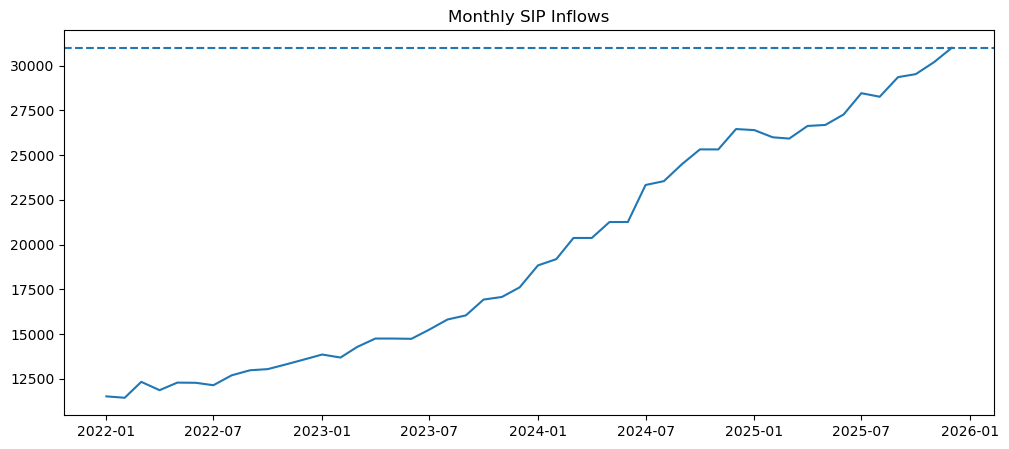

In [71]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.axhline(
    31002,
    linestyle="--"
)

plt.title("Monthly SIP Inflows")

plt.show()

Insights

1.Monthly SIP inflows increased significantly from 2022 to 2025.

2.The industry crossed the ₹31,002 crore milestone by the end of 2025.

3.The trend reflects growing confidence in systematic investing.

4.SIPs continue to be a major driver of mutual fund industry growth.

# Category Inflow Heatmap

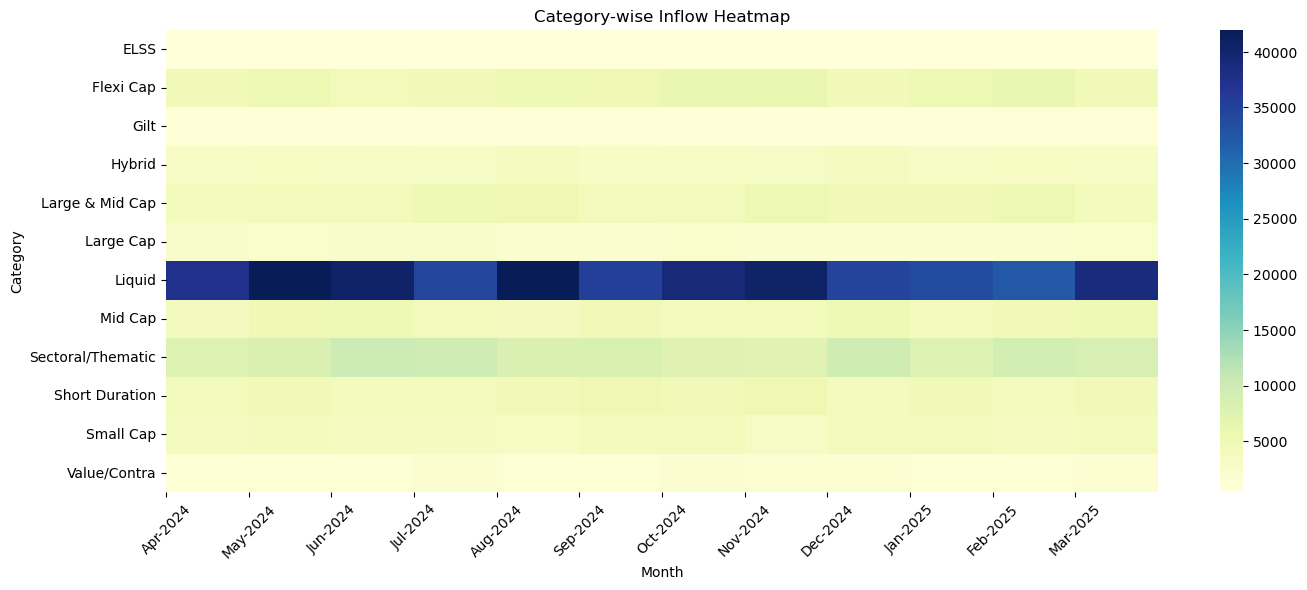

In [76]:
category["month"] = pd.to_datetime(category["month"])

pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.xticks(
    ticks=range(len(pivot.columns)),
    labels=[d.strftime("%b-%Y") for d in pivot.columns],
    rotation=45
)

plt.show()

Insights

1.Liquid and debt-oriented categories show consistently high inflows.

2.Inflow patterns vary substantially across categories and time periods.

3.Certain categories experience periodic spikes, indicating changing investor preferences.

4.The heatmap highlights diversification of investment flows across categories.

# SIP Amount by State

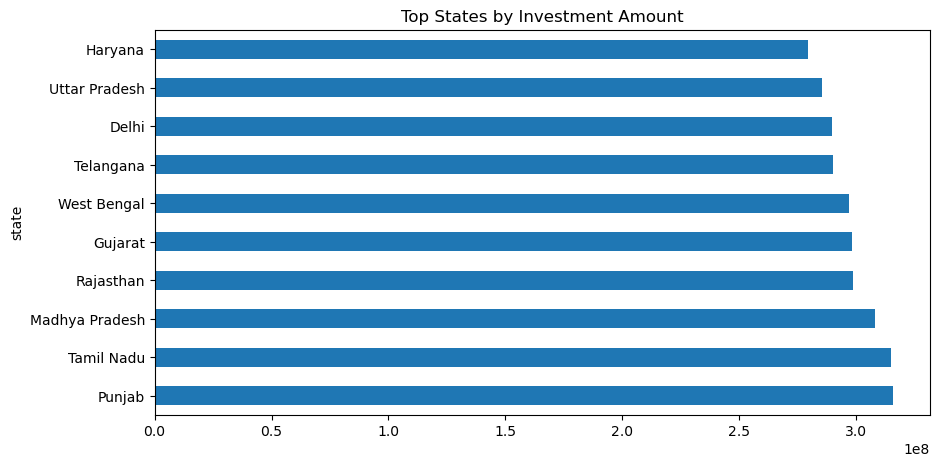

In [83]:
state_sip = (
    txn.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_sip.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Top States by Investment Amount")

plt.show()

Insights

1.Punjab, Tamil Nadu and Madhya Pradesh appear among the highest contributors.

2.Investment participation is geographically diversified across states.

3.No single state overwhelmingly dominates investment activity.

4.Mutual fund adoption is expanding across multiple regions.

# SIP Boxplot by Age Group

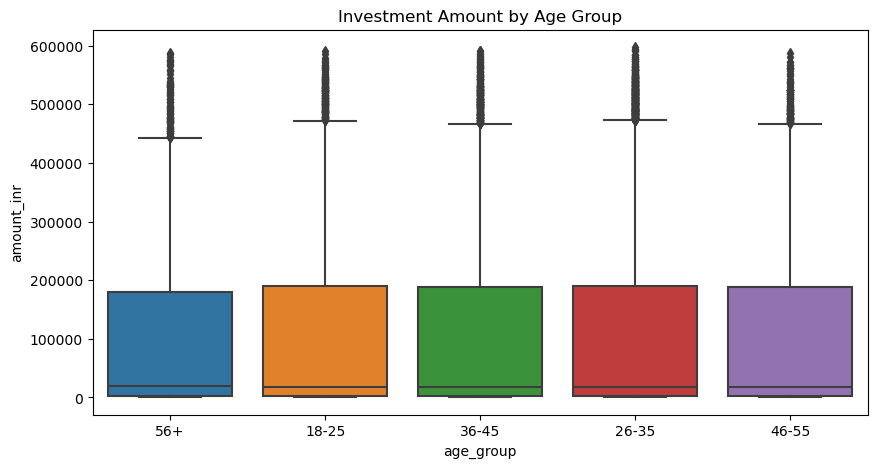

In [86]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "Investment Amount by Age Group"
)

plt.show()

Insights

1.Investment amounts vary significantly within each age group.

2.All age groups contain both low-value and high-value investors.

3.Median investment levels appear relatively similar across age groups.

4.A few high-value outliers indicate participation from affluent investors.

# T30 vs B30

In [89]:
txn["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

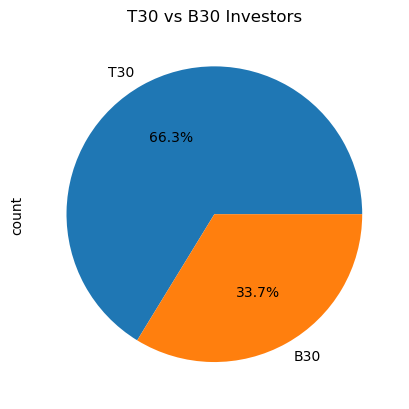

In [91]:
txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investors")

plt.show()

Insights

1.T30 cities account for approximately 66.3% of investors.

2.B30 cities contribute approximately 33.7%.

3.Metropolitan regions continue to dominate mutual fund participation.

4.Significant participation from B30 cities indicates increasing financial penetration beyond major urban centers.

# Folio Count Growth

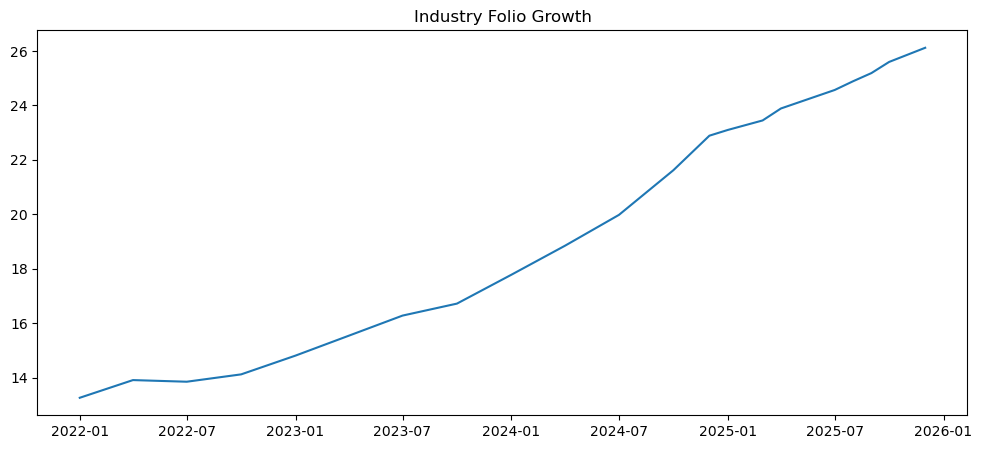

In [96]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title(
    "Industry Folio Growth"
)

plt.show()

Insights

1.Total folios increased steadily between 2022 and 2025.

2.Investor participation nearly doubled during the period.

3.Growth accelerated after 2024.

4.The trend reflects increasing adoption of mutual funds as an investment vehicle.

# Correlation Matrix

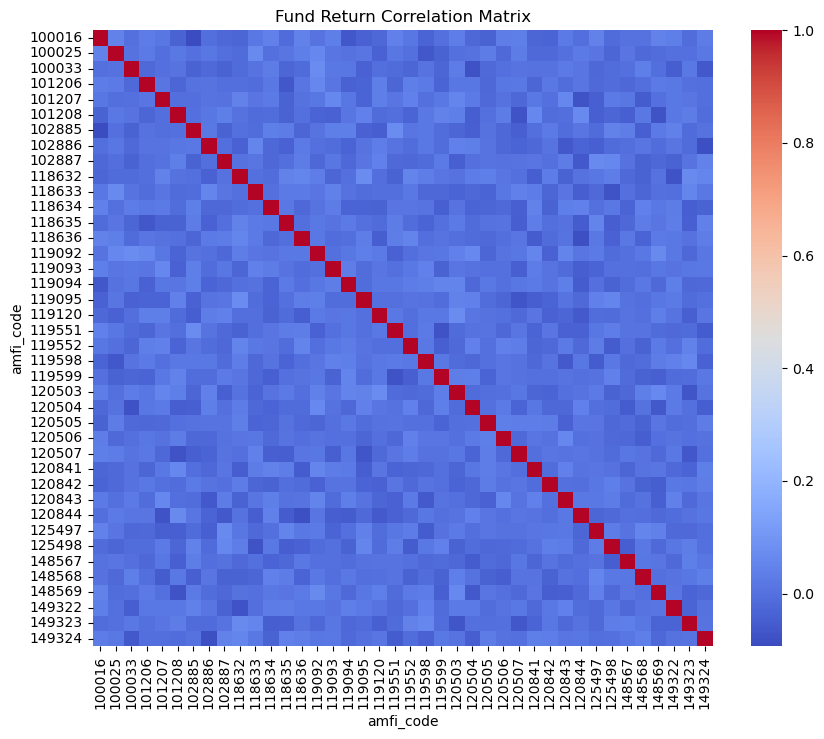

In [99]:
nav["daily_return"] = (
    nav.groupby("amfi_code")
    ["nav"]
    .pct_change()
)

pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

corr = pivot.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title(
    "Fund Return Correlation Matrix"
)

plt.show()

Insights

1.Most funds exhibit positive correlations with each other.

2.Equity-oriented schemes tend to move in similar market conditions.

3.Correlation levels vary across schemes, indicating diversification opportunities.

4.No evidence of extreme negative correlations is visible.

# Sector Distribution

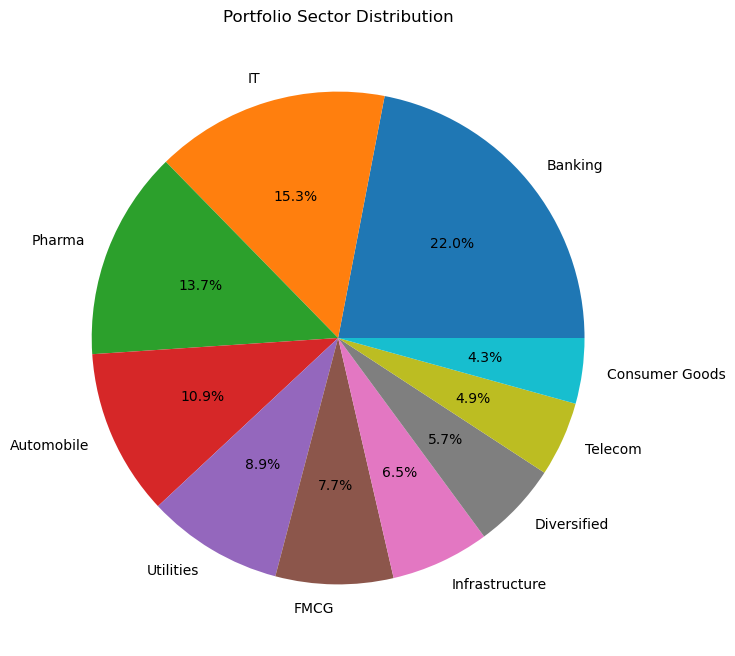

In [102]:
sector = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

sector.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title(
    "Portfolio Sector Distribution"
)

plt.ylabel("")

plt.show()

Insights

1.Banking is the largest sector allocation across portfolios.

2.IT and Pharma also represent significant portfolio exposure.

3.Sector allocation is diversified across multiple industries.

4.Defensive and growth sectors both have meaningful representation.

# Key Findings

1. Most mutual fund schemes exhibited positive NAV growth between 2022 and 2026.

2. SBI Mutual Fund maintained the highest AUM among major fund houses.

3. Monthly SIP inflows increased steadily and crossed ₹31,002 crore by December 2025.

4. Equity schemes dominate the mutual fund landscape.

5. Investors aged 26–35 represent the largest investor segment.

6. SIP transactions significantly outnumber lumpsum and redemption transactions.

7. T30 cities account for nearly two-thirds of the investor base.

8. Industry folio count grew substantially from 2022 to 2025.

9. Banking remains the largest sector allocation across fund portfolios.

10. Higher-risk funds generally demonstrate higher return potential, supporting the risk-return trade-off.